In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Resolve project root automatically.
cwd = os.getcwd()

if os.path.exists(os.path.join(cwd, "data", "master_dataset.csv")):
    PROJECT_ROOT = cwd
elif os.path.exists(os.path.join(cwd, "..", "data", "master_dataset.csv")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    raise FileNotFoundError("Cannot find data/master_dataset.csv. Please run this notebook inside the project folder.")

PHASE1_DIR = os.path.join(PROJECT_ROOT, "phase1_2d_baseline")
sys.path.insert(0, PHASE1_DIR)

from model_2d import FallCNNLSTM

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH


In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "master_dataset.csv")

BINARY_CHECKPOINT_PATH = os.path.join(
    PROJECT_ROOT,
    "phase1_2d_baseline",
    "checkpoints",
    "best_model_2d_binary.pt"
)

ACTION_CHECKPOINT_PATH = os.path.join(
    PROJECT_ROOT,
    "phase1_2d_baseline",
    "checkpoints",
    "best_model_2d_action.pt"
)

SEQUENCE_LENGTH = 60
STRIDE = 15
BATCH_SIZE = 64
RANDOM_SEED = 42

BINARY_CLASS_NAMES = ["Not_Fall", "Fall"]
ACTION_CLASS_NAMES = ["Sitting", "Sleeping", "Standing", "Walking"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_columns = {"source_file", "binary_label", "action_label", "action_name"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing columns in master_dataset.csv: {missing_columns}. "
        "Please rerun 02_preprocess_2d.ipynb with hierarchical labels."
    )

df.head()

Dataset shape: (651989, 39)
Columns:
['frame', 'x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'source_file', 'binary_label', 'action_label', 'action_name']


,frame,x0,y0,x1,y1,x2,y2,x3,y3,x4,...,x14,y14,x15,y15,x16,y16,source_file,binary_label,action_label,action_name
0,0,1115.062866,482.301086,1118.723511,471.453827,1114.744629,467.069550,1102.419067,437.462036,1087.692993,...,737.119507,611.638672,464.921570,738.099854,450.203796,742.105347,Fall_f_raw_b_1_B_D_0001.csv,1,-1,Fall
1,1,1124.277100,484.882599,1124.451050,473.394836,1126.286377,470.247711,1100.747070,437.777985,1100.417480,...,743.972900,614.395630,458.776886,754.806152,445.809265,760.247803,Fall_f_raw_b_1_B_D_0001.csv,1,-1,Fall
2,2,1133.458740,482.752899,1129.986816,471.776825,1133.788452,471.235779,1104.280273,438.365112,1107.900635,...,761.317017,625.895264,483.089478,730.985779,472.366241,731.921814,Fall_f_raw_b_1_B_D_0001.csv,1,-1,Fall
3,3,1138.404541,486.282227,1133.653564,474.073608,1137.891846,475.147797,1108.258057,439.880737,1110.960693,...,776.237000,626.797485,530.630005,716.554871,474.819855,724.166321,Fall_f_raw_b_1_B_D_0001.csv,1,-1,Fall
4,4,1137.641235,487.493164,1132.632935,476.117004,1137.679199,476.289612,1106.719238,444.506012,1111.005737,...,771.785889,633.047852,565.203979,713.817810,481.958221,738.396790,Fall_f_raw_b_1_B_D_0001.csv,1,-1,Fall


In [4]:
binary_video_df = df[["source_file", "binary_label"]].drop_duplicates()
action_video_df = (
    df[df["action_label"] != -1][["source_file", "action_label", "action_name"]]
    .drop_duplicates()
)

print("Frame-level binary distribution:")
print(df["binary_label"].value_counts().sort_index())
print(df["binary_label"].value_counts(normalize=True).sort_index())

print("\nVideo-level binary distribution:")
print(binary_video_df["binary_label"].value_counts().sort_index())
print(binary_video_df["binary_label"].value_counts(normalize=True).sort_index())

print("\nVideo-level action distribution:")
print(action_video_df["action_name"].value_counts())
print(action_video_df["action_name"].value_counts(normalize=True))

Frame-level binary distribution:
binary_label
0    382294
1    269695
Name: count, dtype: int64
binary_label
0    0.58635
1    0.41365
Name: proportion, dtype: float64

Video-level binary distribution:
binary_label
0    2485
1    2998
Name: count, dtype: int64
binary_label
0    0.453219
1    0.546781
Name: proportion, dtype: float64

Video-level action distribution:
action_name
Sitting     959
Sleeping    523
Standing    513
Walking     490
Name: count, dtype: int64
action_name
Sitting     0.385915
Sleeping    0.210463
Standing    0.206439
Walking     0.197183
Name: proportion, dtype: float64


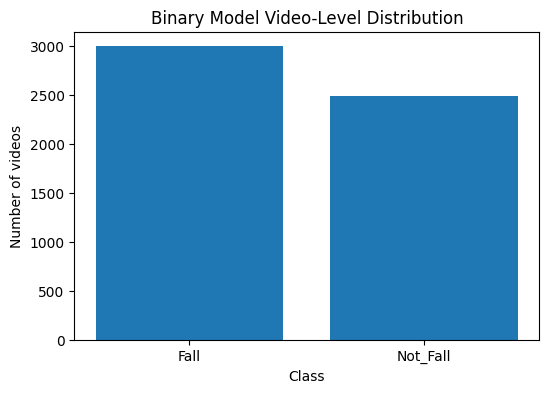

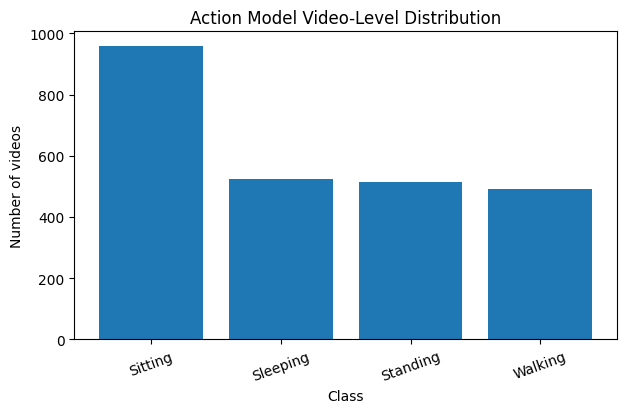

In [5]:
binary_counts = binary_video_df["binary_label"].map({0: "Not_Fall", 1: "Fall"}).value_counts()
action_counts = action_video_df["action_name"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(binary_counts.index, binary_counts.values)
plt.title("Binary Model Video-Level Distribution")
plt.xlabel("Class")
plt.ylabel("Number of videos")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(action_counts.index, action_counts.values)
plt.title("Action Model Video-Level Distribution")
plt.xlabel("Class")
plt.ylabel("Number of videos")
plt.xticks(rotation=20)
plt.show()

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)


def add_pose_features(video_df):
    keypoint_cols = []

    for i in range(17):
        keypoint_cols.extend([f"x{i}", f"y{i}"])

    coords = video_df[keypoint_cols].values.astype(np.float32)

    xs = coords[:, 0::2]
    ys = coords[:, 1::2]

    min_x = xs.min(axis=1, keepdims=True)
    max_x = xs.max(axis=1, keepdims=True)
    min_y = ys.min(axis=1, keepdims=True)
    max_y = ys.max(axis=1, keepdims=True)

    width = max_x - min_x
    height = max_y - min_y

    eps = 1e-6

    center_x = (min_x + max_x) / 2.0
    center_y = (min_y + max_y) / 2.0

    scale = np.maximum(width, height) + eps

    norm_xs = (xs - center_x) / scale
    norm_ys = (ys - center_y) / scale

    normalized_coords = np.empty_like(coords)
    normalized_coords[:, 0::2] = norm_xs
    normalized_coords[:, 1::2] = norm_ys

    aspect_ratio = height / (width + eps)
    norm_width = width / (scale + eps)
    norm_height = height / (scale + eps)

    center_x_norm = center_x / 1920.0
    center_y_norm = center_y / 1080.0

    center = np.concatenate([center_x, center_y], axis=1)
    velocity = np.zeros((len(center), 1), dtype=np.float32)

    if len(center) > 1:
        diff = center[1:] - center[:-1]
        velocity[1:, 0] = np.linalg.norm(diff, axis=1)

    handcrafted = np.concatenate(
        [
            aspect_ratio,
            norm_width,
            norm_height,
            center_x_norm,
            center_y_norm,
            velocity
        ],
        axis=1
    ).astype(np.float32)

    features = np.concatenate([normalized_coords, handcrafted], axis=1)

    return features


def create_sequences_from_video(video_df, label_column, sequence_length=60, stride=15):
    video_df = video_df.sort_values("frame").reset_index(drop=True)

    label = int(video_df[label_column].iloc[0])
    features = add_pose_features(video_df)

    sequences = []
    labels = []

    n_frames = len(features)

    if n_frames == 0:
        return sequences, labels

    if n_frames < sequence_length:
        pad_len = sequence_length - n_frames
        pad = np.repeat(features[-1:], pad_len, axis=0)
        padded_features = np.concatenate([features, pad], axis=0)

        sequences.append(padded_features)
        labels.append(label)

    else:
        for start in range(0, n_frames - sequence_length + 1, stride):
            end = start + sequence_length
            sequences.append(features[start:end])
            labels.append(label)

    return sequences, labels


class FallSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(np.array(sequences), dtype=torch.float32)
        self.labels = torch.tensor(np.array(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [7]:
def build_test_sequences(task):
    if task == "binary":
        task_df = df.copy()
        label_column = "binary_label"
        class_names = BINARY_CLASS_NAMES
        checkpoint_path = BINARY_CHECKPOINT_PATH

    elif task == "action":
        task_df = df[df["action_label"] != -1].reset_index(drop=True)
        label_column = "action_label"
        class_names = ACTION_CLASS_NAMES
        checkpoint_path = ACTION_CHECKPOINT_PATH

    else:
        raise ValueError("task must be 'binary' or 'action'")

    video_label_df = task_df[["source_file", label_column]].drop_duplicates().reset_index(drop=True)

    _, test_files = train_test_split(
        video_label_df,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=video_label_df[label_column]
    )

    test_file_set = set(test_files["source_file"])
    test_df = task_df[task_df["source_file"].isin(test_file_set)].reset_index(drop=True)

    test_sequences = []
    test_labels = []

    for source_file, video_df in test_df.groupby("source_file"):
        seqs, labs = create_sequences_from_video(
            video_df,
            label_column=label_column,
            sequence_length=SEQUENCE_LENGTH,
            stride=STRIDE
        )
        test_sequences.extend(seqs)
        test_labels.extend(labs)

    return test_sequences, test_labels, class_names, checkpoint_path


def evaluate_checkpoint(task):
    test_sequences, test_labels, class_names, checkpoint_path = build_test_sequences(task)

    test_dataset = FallSequenceDataset(test_sequences, test_labels)
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    checkpoint = torch.load(checkpoint_path, map_location=device)

    input_dim = checkpoint.get("input_dim", test_sequences[0].shape[1])
    num_classes = checkpoint.get("num_classes", len(class_names))

    model = FallCNNLSTM(
        input_dim=input_dim,
        num_classes=num_classes,
        cnn_channels=128,
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.3
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)

    print("=" * 60)
    print(f"{task.upper()} MODEL")
    print("=" * 60)
    print("Checkpoint:", checkpoint_path)
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "task": task,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm,
        "class_names": class_names,
    }


def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(range(len(class_names)), class_names, rotation=30)
    plt.yticks(range(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

BINARY MODEL
Checkpoint: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase1_2d_baseline\checkpoints\best_model_2d_binary.pt
Accuracy: 0.9356543930003646
Macro F1: 0.9279590416358228
Weighted F1: 0.9358389440927657

Classification Report:
              precision    recall  f1-score   support

    Not_Fall       0.96      0.95      0.95      3661
        Fall       0.89      0.92      0.90      1825

    accuracy                           0.94      5486
   macro avg       0.93      0.93      0.93      5486
weighted avg       0.94      0.94      0.94      5486


Confusion Matrix:
[[3463  198]
 [ 155 1670]]


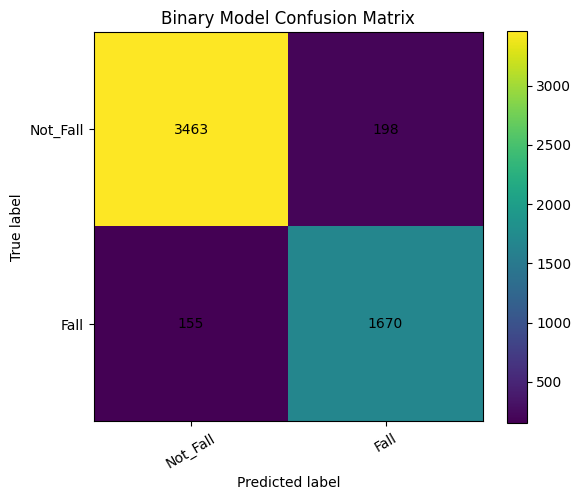

In [8]:
binary_result = evaluate_checkpoint("binary")

plot_confusion_matrix(
    binary_result["confusion_matrix"],
    binary_result["class_names"],
    "Binary Model Confusion Matrix"
)

ACTION MODEL
Checkpoint: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase1_2d_baseline\checkpoints\best_model_2d_action.pt
Accuracy: 0.96995596995597
Macro F1: 0.9604054620510493
Weighted F1: 0.9698664681435224

Classification Report:
              precision    recall  f1-score   support

     Sitting       0.95      0.94      0.94       991
    Sleeping       0.95      0.93      0.94       646
    Standing       0.95      0.97      0.96       447
     Walking       0.99      1.00      1.00      1777

    accuracy                           0.97      3861
   macro avg       0.96      0.96      0.96      3861
weighted avg       0.97      0.97      0.97      3861


Confusion Matrix:
[[ 932   30   24    5]
 [  43  603    0    0]
 [   8    1  433    5]
 [   0    0    0 1777]]


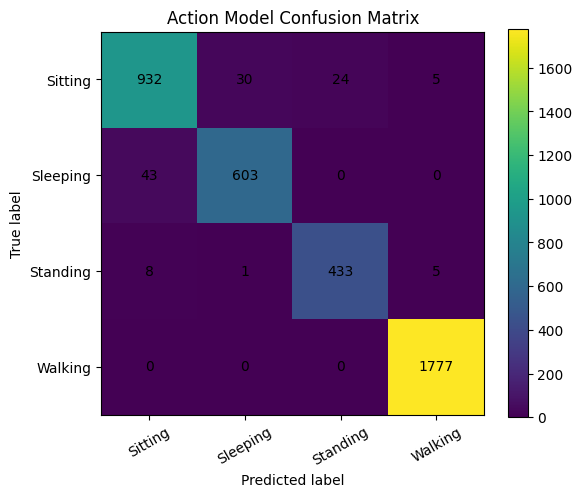

In [9]:
action_result = evaluate_checkpoint("action")

plot_confusion_matrix(
    action_result["confusion_matrix"],
    action_result["class_names"],
    "Action Model Confusion Matrix"
)

In [10]:
summary_df = pd.DataFrame([
    {
        "Model": "Binary Fall Detection",
        "Classes": "Not_Fall / Fall",
        "Accuracy": binary_result["accuracy"],
        "Macro F1": binary_result["macro_f1"],
        "Weighted F1": binary_result["weighted_f1"],
    },
    {
        "Model": "Action Recognition",
        "Classes": "Sitting / Sleeping / Standing / Walking",
        "Accuracy": action_result["accuracy"],
        "Macro F1": action_result["macro_f1"],
        "Weighted F1": action_result["weighted_f1"],
    }
])

summary_df

,Model,Classes,Accuracy,Macro F1,Weighted F1
0,Binary Fall Detection,Not_Fall / Fall,0.935654,0.927959,0.935839
1,Action Recognition,Sitting / Sleeping / Standing / Walking,0.969956,0.960405,0.969866
